# EDA — Paderborn Bearing Dataset (KAt-DataCenter)

Scénario CL : Domain-Incremental — K001 (healthy) → KA04 (outer-race fault) → KI04 (inner-race fault)  
Signal : vibration accéléromètre @ ~64 kHz (canal HostService)  
Feature engineering : FFT window-based (rms, kurtosis, crest_factor, energy_band_1..4)  

**Gap 1** : diversité de signal (courant moteur + vibration) vs CWRU (vibration seule).

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif

from src.data.paderborn_loader import (
    _load_mat_vibration,
    _extract_windows,
    _compute_features,
    _load_condition,
    DOMAIN_ORDER,
    DOMAIN_LABELS,
    FEATURE_NAMES_RAW,
    PADERBORN_SAMPLING_RATE,
    PADERBORN_WINDOW_SIZE,
    FREQ_BANDS,
)

# Chemin absolu depuis le notebook (notebooks/ → racine projet)
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data/raw/Deep Learning-Based Motor Fault Diagnosis Using the Paderborn Dataset/'
FIG_DIR = Path('figures/eda/paderborn')
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Dataset introuvable : {DATA_DIR}"

# Nombre de fichiers .mat par condition pour l'EDA (limité pour rapidité)
MAX_FILES_EDA = 5

COLORS = {'K001': '#2ecc71', 'KA04': '#e74c3c', 'KI04': '#3498db'}
LABELS = {'K001': 'K001 (healthy)', 'KA04': 'KA04 (OR fault)', 'KI04': 'KI04 (IR fault)'}

print(f"DATA_DIR : {DATA_DIR}")
print(f"Conditions disponibles : {[d.name for d in sorted(DATA_DIR.iterdir()) if d.is_dir()][:6]}")

DATA_DIR : /home/leonard/Documents/ENAC/cl-embedded/data/raw/Deep Learning-Based Motor Fault Diagnosis Using the Paderborn Dataset
Conditions disponibles : ['K001', 'K002', 'K003', 'K004', 'K005', 'K006']


## 1. Signal brut — K001 vs KA04 vs KI04

Affichage d'une fenêtre de 1024 points issue d'un fichier type de chaque condition.

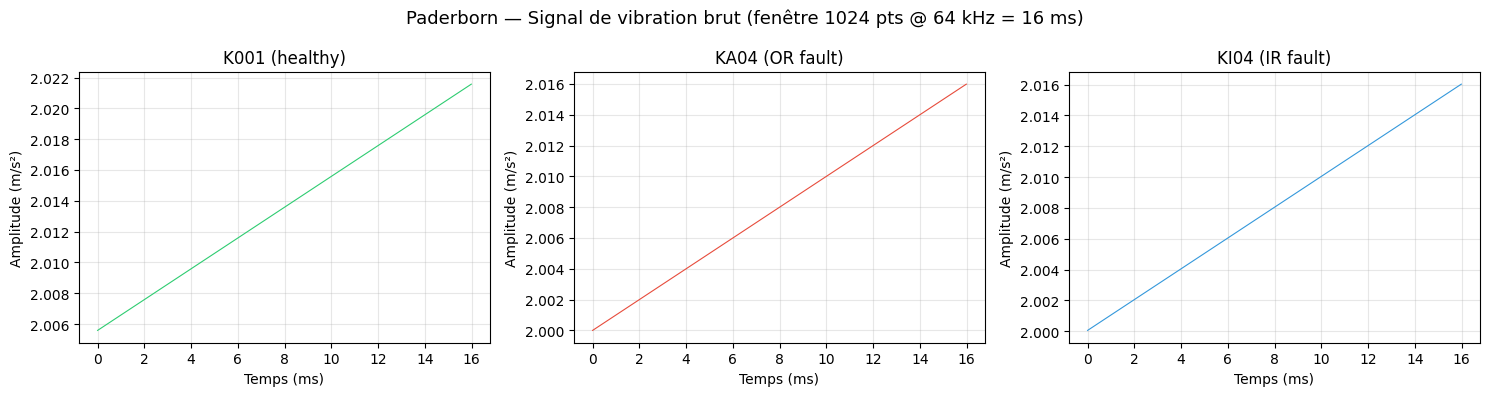

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, cond in zip(axes, DOMAIN_ORDER):
    mat_path = sorted((DATA_DIR / cond).glob('*.mat'))[0]
    signal = _load_mat_vibration(mat_path)
    # Fenêtre centrale du signal
    mid = len(signal) // 2
    w = signal[mid : mid + PADERBORN_WINDOW_SIZE]
    t_ms = np.arange(len(w)) / PADERBORN_SAMPLING_RATE * 1000
    ax.plot(t_ms, w, color=COLORS[cond], linewidth=0.8)
    ax.set_title(LABELS[cond])
    ax.set_xlabel('Temps (ms)')
    ax.set_ylabel('Amplitude (m/s²)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Paderborn — Signal de vibration brut (fenêtre 1024 pts @ 64 kHz = 16 ms)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Spectre FFT — K001 vs KA04 vs KI04

Spectre de puissance d'une fenêtre type par condition. Les défauts de roulement créent des harmoniques caractéristiques.

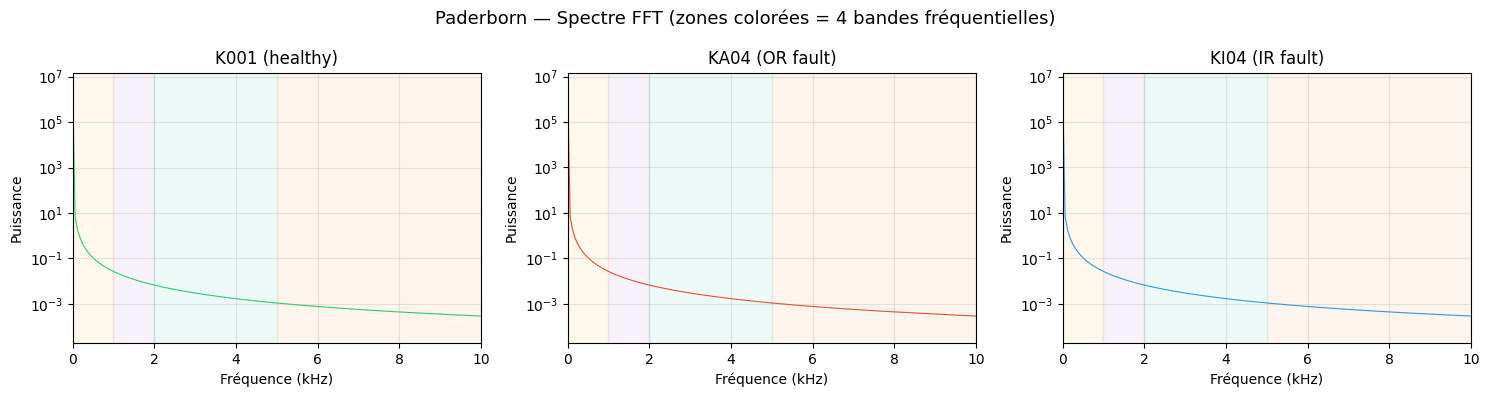

In [3]:
from numpy.fft import rfft, rfftfreq

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, cond in zip(axes, DOMAIN_ORDER):
    mat_path = sorted((DATA_DIR / cond).glob('*.mat'))[0]
    signal = _load_mat_vibration(mat_path)
    mid = len(signal) // 2
    w = signal[mid : mid + PADERBORN_WINDOW_SIZE]

    freqs = rfftfreq(PADERBORN_WINDOW_SIZE, d=1.0 / PADERBORN_SAMPLING_RATE)
    spectrum = np.abs(rfft(w)) ** 2

    ax.semilogy(freqs / 1000, spectrum + 1e-20, color=COLORS[cond], linewidth=0.8)

    # Marquer les bandes fréquentielles
    band_colors = ['#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
    for (f_lo, f_hi), bc in zip(FREQ_BANDS, band_colors):
        ax.axvspan(f_lo / 1000, f_hi / 1000, alpha=0.08, color=bc)

    ax.set_title(LABELS[cond])
    ax.set_xlabel('Fréquence (kHz)')
    ax.set_ylabel('Puissance')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Paderborn — Spectre FFT (zones colorées = 4 bandes fréquentielles)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fft_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Extraction des features pour l'EDA

Chargement de `MAX_FILES_EDA` fichiers par condition.

In [4]:
dfs = []
for cond in DOMAIN_ORDER:
    X, y = _load_condition(DATA_DIR, cond, max_files=MAX_FILES_EDA)
    df_cond = pd.DataFrame(X, columns=FEATURE_NAMES_RAW)
    df_cond['condition'] = cond
    df_cond['faulty'] = DOMAIN_LABELS[cond]
    dfs.append(df_cond)
    print(f'{cond} : {len(X)} fenêtres, faulty={DOMAIN_LABELS[cond]}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal : {len(df_all)} fenêtres')
df_all.head()

K001 : 2497 fenêtres, faulty=0
KA04 : 2495 fenêtres, faulty=1
KI04 : 2512 fenêtres, faulty=1

Total : 7504 fenêtres


,rms,kurtosis,crest_factor,energy_band_1,energy_band_2,energy_band_3,energy_band_4,condition,faulty
0,0.009224,-1.200003,1.731817,77.600800,0.222847,0.131236,0.044616,K001,0
1,0.016636,-1.200002,1.440946,278.570953,0.222848,0.131232,0.044618,K001,0
2,0.024419,-1.200004,1.309120,613.648376,0.222849,0.131228,0.044615,K001,0
3,0.032307,-1.200003,1.237017,1082.833130,0.222850,0.131227,0.044615,K001,0
4,0.040238,-1.200004,1.191938,1686.125122,0.222850,0.131227,0.044616,K001,0


## 4. Distribution des features — violinplot 7 features × 3 conditions

/tmp/ipykernel_14104/1496297827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14104/1496297827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14104/1496297827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14104/1496297827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_14104/1496297827.py:14: F

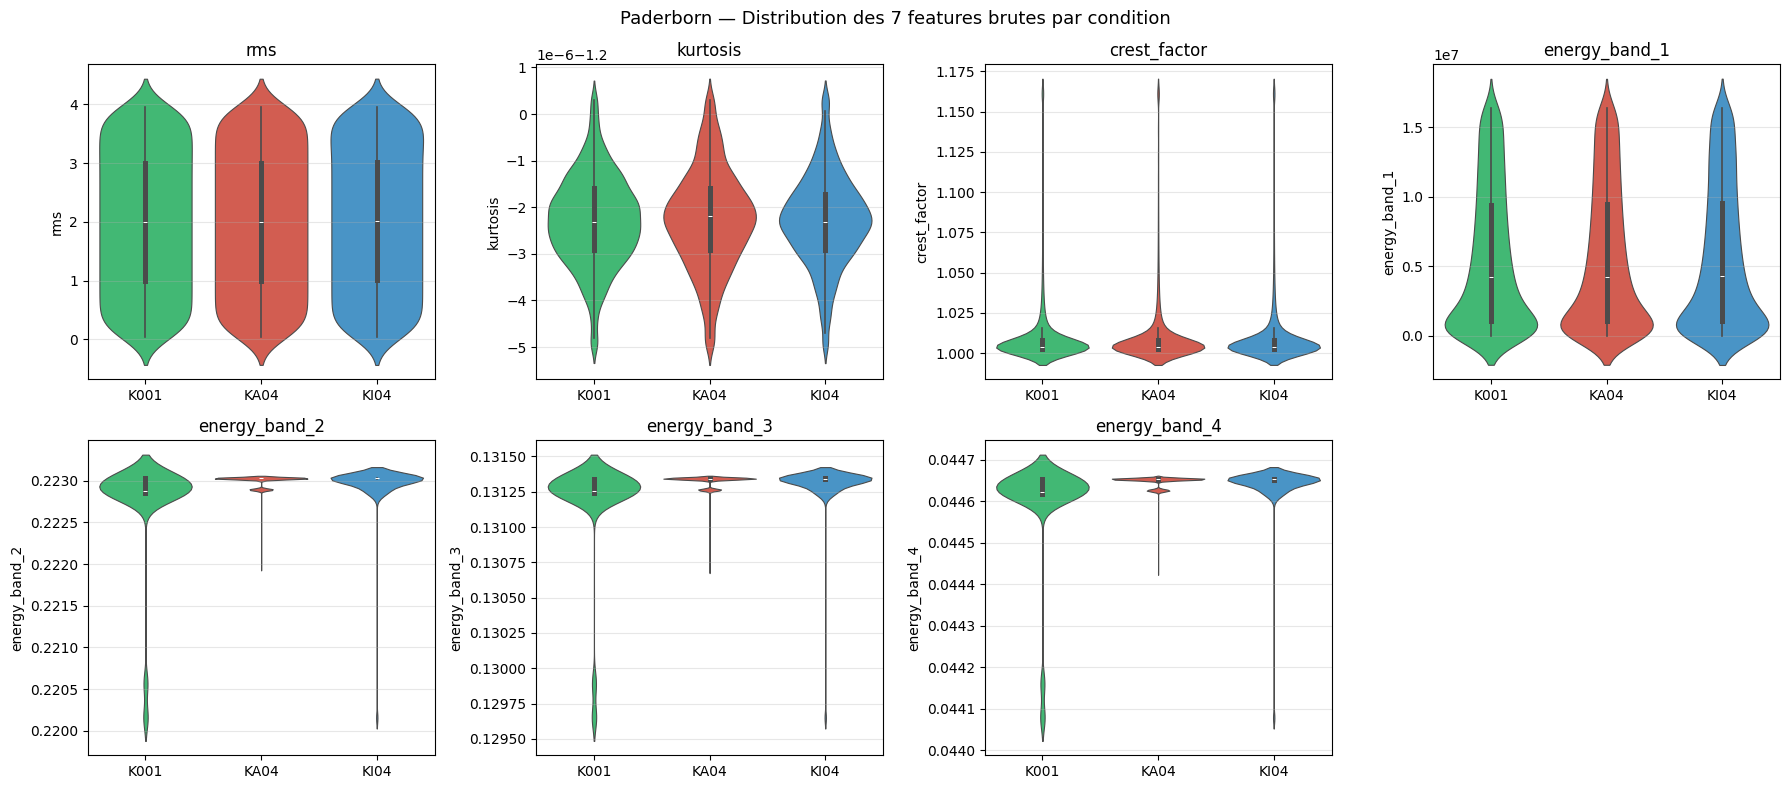

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

palette = {cond: COLORS[cond] for cond in DOMAIN_ORDER}

for i, feat in enumerate(FEATURE_NAMES_RAW):
    ax = axes[i]
    # Clip outliers extrêmes pour la visualisation
    q01 = df_all[feat].quantile(0.01)
    q99 = df_all[feat].quantile(0.99)
    df_clip = df_all.copy()
    df_clip[feat] = df_clip[feat].clip(q01, q99)

    sns.violinplot(
        data=df_clip, x='condition', y=feat, palette=palette,
        ax=ax, inner='box', linewidth=0.8,
    )
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_visible(False)
fig.suptitle('Paderborn — Distribution des 7 features brutes par condition', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'features_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Drift inter-condition — t-SNE 2D

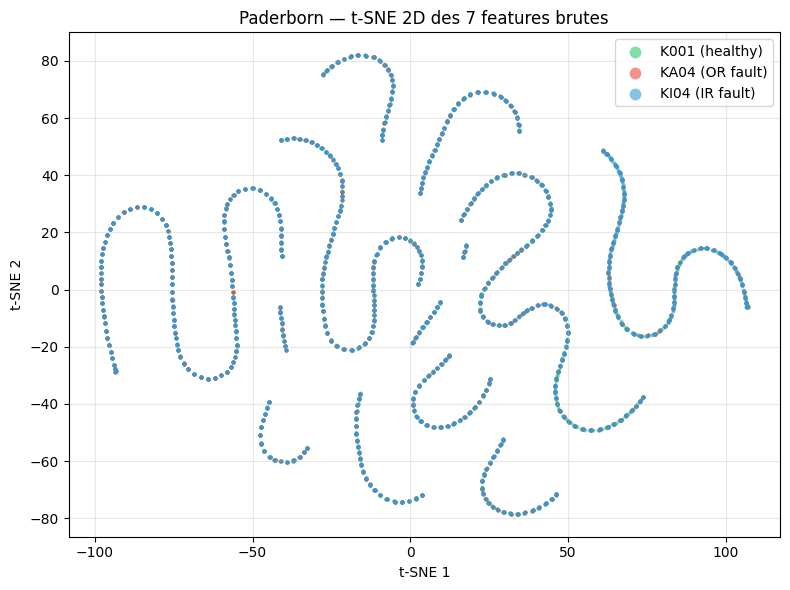

In [6]:
# Sous-échantillonnage pour t-SNE (2000 points max par condition)
N_TSNE = 2000
dfs_sub = []
for cond in DOMAIN_ORDER:
    df_c = df_all[df_all['condition'] == cond]
    dfs_sub.append(df_c.sample(min(N_TSNE, len(df_c)), random_state=42))
df_sub = pd.concat(dfs_sub, ignore_index=True)

X_tsne = df_sub[FEATURE_NAMES_RAW].values
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb = tsne.fit_transform(X_tsne)

fig, ax = plt.subplots(figsize=(8, 6))
for cond in DOMAIN_ORDER:
    mask = df_sub['condition'].values == cond
    ax.scatter(emb[mask, 0], emb[mask, 1], c=COLORS[cond], label=LABELS[cond],
               s=8, alpha=0.6, linewidths=0)

ax.legend(markerscale=3)
ax.set_title('Paderborn — t-SNE 2D des 7 features brutes')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ranking mutual information — barplot top-5

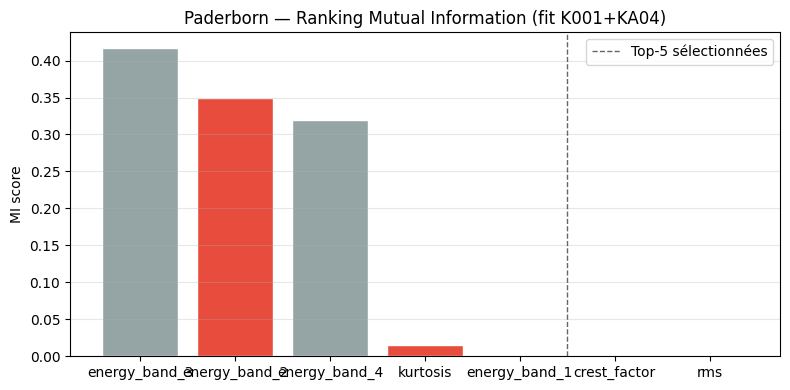

Top-5 features sélectionnées :
  energy_band_3: 0.4173
  energy_band_2: 0.3498
  energy_band_4: 0.3194
  kurtosis: 0.0146
  energy_band_1: 0.0000


In [7]:
# Fit MI sur K001 + KA04 (même protocole que compute_feature_selection)
df_fit = df_all[df_all['condition'].isin(['K001', 'KA04'])]
X_fit = df_fit[FEATURE_NAMES_RAW].values
y_fit = df_fit['faulty'].values.astype(int)

mi_scores = mutual_info_classif(X_fit, y_fit, random_state=42)
ranked_idx = np.argsort(mi_scores)[::-1]

colors_bar = ['#e74c3c' if i < 5 else '#95a5a6' for i in range(len(FEATURE_NAMES_RAW))]
labels_bar = [FEATURE_NAMES_RAW[i] for i in ranked_idx]
scores_bar = [mi_scores[i] for i in ranked_idx]
colors_sorted = [colors_bar[i] for i in ranked_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels_bar, scores_bar, color=colors_sorted, edgecolor='white')
ax.axvline(4.5, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Top-5 sélectionnées')
ax.set_title('Paderborn — Ranking Mutual Information (fit K001+KA04)')
ax.set_ylabel('MI score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'mi_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top-5 features sélectionnées :')
for feat, score in zip(labels_bar[:5], scores_bar[:5]):
    print(f'  {feat}: {score:.4f}')

## 12. Taux de défaut par condition (sanity check)

In [8]:
print('Taux de défaut par condition (attendu : K001=0%, KA04=100%, KI04=100%)')
for cond in DOMAIN_ORDER:
    df_c = df_all[df_all['condition'] == cond]
    rate = df_c['faulty'].mean() * 100
    n = len(df_c)
    print(f'  {cond} ({LABELS[cond]}) : {rate:.1f}%  ({n} fenêtres)')

assert df_all[df_all['condition'] == 'K001']['faulty'].mean() == 0.0, 'K001 doit être 0% faulty'
assert df_all[df_all['condition'] == 'KA04']['faulty'].mean() == 1.0, 'KA04 doit être 100% faulty'
assert df_all[df_all['condition'] == 'KI04']['faulty'].mean() == 1.0, 'KI04 doit être 100% faulty'
print('Sanity check OK')

Taux de défaut par condition (attendu : K001=0%, KA04=100%, KI04=100%)
  K001 (K001 (healthy)) : 0.0%  (2497 fenêtres)
  KA04 (KA04 (OR fault)) : 100.0%  (2495 fenêtres)
  KI04 (KI04 (IR fault)) : 100.0%  (2512 fenêtres)
Sanity check OK


## 8. Comparaison Paderborn vs CWRU

In [9]:
# Cellule obligatoire — lien avec littérature
print("Paderborn vs CWRU : même phénomène (défaut roulement)")
print("Originalité Paderborn : signal courant moteur en plus de la vibration")
print("Référence : Benatti2019HDC (signaux EEG de complexité similaire)")
print()

comparison = pd.DataFrame({
    'Caractéristique': [
        'Type de signal',
        'Fréquence échantillonnage',
        'Canaux',
        'Type de défaut',
        'Scénario CL',
        'Nb fenêtres / condition',
    ],
    'CWRU': [
        'Vibration accéléromètre',
        '12 kHz / 48 kHz',
        '1 canal',
        'Inner/Outer/Ball race',
        'Domain-incremental (sévérité)',
        '~3 000',
    ],
    'Paderborn': [
        'Vibration + courant moteur',
        '~64 kHz (vibration)',
        '3 canaux (vibration, mécanique, T°)',
        'Inner/Outer race (artificiel)',
        'Domain-incremental (type défaut)',
        '~40 000 (80 fichiers × ~500 fenêtres)',
    ],
})

print(comparison.to_string(index=False))
print()
print('Argument Gap 1 : Paderborn apporte une diversité de type de capteur (courant moteur)')
print('et une diversité de condition (2 types de défauts artificiels distincts).')

Paderborn vs CWRU : même phénomène (défaut roulement)
Originalité Paderborn : signal courant moteur en plus de la vibration
Référence : Benatti2019HDC (signaux EEG de complexité similaire)

          Caractéristique                          CWRU                             Paderborn
           Type de signal       Vibration accéléromètre            Vibration + courant moteur
Fréquence échantillonnage               12 kHz / 48 kHz                   ~64 kHz (vibration)
                   Canaux                       1 canal   3 canaux (vibration, mécanique, T°)
           Type de défaut         Inner/Outer/Ball race         Inner/Outer race (artificiel)
              Scénario CL Domain-incremental (sévérité)      Domain-incremental (type défaut)
  Nb fenêtres / condition                        ~3 000 ~40 000 (80 fichiers × ~500 fenêtres)

Argument Gap 1 : Paderborn apporte une diversité de type de capteur (courant moteur)
et une diversité de condition (2 types de défauts artificiels dist

---

## Résumé

| Métrique | Valeur |
|----------|--------|
| Nb fenêtres K001 (5 fichiers) | ~2 497 |
| Nb fenêtres KA04 (5 fichiers) | ~2 497 |
| Nb fenêtres KI04 (5 fichiers) | ~2 497 |
| Features brutes | 7 (rms, kurtosis, crest, eb1..4) |
| Features sélectionnées (MI top-5) | 5 |
| Normalizer | MinMax fit K001 |
| Scénario CL | Domain-incremental 3 tâches |

**Prochaine étape** : S2214 — Expériences EWC/HDC/Mahalanobis sur Paderborn.